In [1]:
from datasets import load_dataset

# Load the SLAKE dataset
dataset = load_dataset("BoKelvin/SLAKE")

# Access the train, validation, and test splits
train_dataset = dataset['train']
validation_dataset = dataset['validation']
test_dataset = dataset['test']

# Example: Print the first example from the training set
print(train_dataset[0])

/home/tpadhi1/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'img_name': 'xmlab1/source.jpg', 'location': 'Abdomen', 'answer': 'MRI', 'modality': 'MRI', 'base_type': 'vqa', 'answer_type': 'OPEN', 'question': 'What modality is used to take this image?', 'qid': 0, 'content_type': 'Modality', 'triple': ['vhead', '_', '_'], 'img_id': 1, 'q_lang': 'en'}


In [2]:
dataset

DatasetDict({
    train: Dataset({
        features: ['img_name', 'location', 'answer', 'modality', 'base_type', 'answer_type', 'question', 'qid', 'content_type', 'triple', 'img_id', 'q_lang'],
        num_rows: 9835
    })
    validation: Dataset({
        features: ['img_name', 'location', 'answer', 'modality', 'base_type', 'answer_type', 'question', 'qid', 'content_type', 'triple', 'img_id', 'q_lang'],
        num_rows: 2099
    })
    test: Dataset({
        features: ['img_name', 'location', 'answer', 'modality', 'base_type', 'answer_type', 'question', 'qid', 'content_type', 'triple', 'img_id', 'q_lang'],
        num_rows: 2094
    })
})

In [3]:
# Display the first sample
print(dataset['train'][0])

# Display the first 5 samples
for i in range(5):
    print(dataset['train'][i])

{'img_name': 'xmlab1/source.jpg', 'location': 'Abdomen', 'answer': 'MRI', 'modality': 'MRI', 'base_type': 'vqa', 'answer_type': 'OPEN', 'question': 'What modality is used to take this image?', 'qid': 0, 'content_type': 'Modality', 'triple': ['vhead', '_', '_'], 'img_id': 1, 'q_lang': 'en'}
{'img_name': 'xmlab1/source.jpg', 'location': 'Abdomen', 'answer': 'MRI', 'modality': 'MRI', 'base_type': 'vqa', 'answer_type': 'OPEN', 'question': 'What modality is used to take this image?', 'qid': 0, 'content_type': 'Modality', 'triple': ['vhead', '_', '_'], 'img_id': 1, 'q_lang': 'en'}
{'img_name': 'xmlab1/source.jpg', 'location': 'Abdomen', 'answer': 'Abdomen', 'modality': 'MRI', 'base_type': 'vqa', 'answer_type': 'OPEN', 'question': 'Which part of the body does this image belong to?', 'qid': 1, 'content_type': 'Position', 'triple': ['vhead', '_', '_'], 'img_id': 1, 'q_lang': 'en'}
{'img_name': 'xmlab1/source.jpg', 'location': 'Abdomen', 'answer': 'T2', 'modality': 'MRI', 'base_type': 'vqa', 'an

In [4]:
from collections import Counter

# # Extract unique answer types
# answer_types = set()
# for item in dataset['train']:
# Create a counter to track first-word frequencies
first_word_counter = Counter()

for item in dataset['train']:
    # only process questions if the language is English which would be known by the key 'q_lang' and value 'en'
    if item['q_lang'] != 'en':
        continue
    # Split and get the first word, lowercase for consistency
    question = item['question']
    words = question.strip().split()
    if len(words) > 0:
        first_word = words[0].lower()
        first_word_counter[first_word] += 1

# At this point, first_word_counter is a dictionary-like object
# containing { first_word: count_of_occurrences }.
print("First word counts:")
for fw, cnt in first_word_counter.items():
    print(f"'{fw}' -> {cnt}")

# If you only need the *set* of first words, you can do:
first_word_set = set(first_word_counter.keys())
print("\nUnique first words:", first_word_set)

First word counts:
'what' -> 1640
'which' -> 819
'does' -> 905
'where' -> 392
'is' -> 492
'are' -> 109
'how' -> 342
'is/are' -> 28
'can' -> 67
'do' -> 88
'in' -> 27
'are/is' -> 10

Unique first words: {'is/are', 'which', 'does', 'what', 'are', 'are/is', 'where', 'how', 'is', 'can', 'in', 'do'}


In [7]:
# ok so we have the first word of the question and the count of the first word in the dataset, i only want 'what' questions
# so i will filter out the first word counter to only contain 'what' questions

question_list = []

for item in dataset['train']:
    # only process questions if the language is English which would be known by the key 'q_lang' and value 'en'
    if item['q_lang'] != 'en':
        continue
    # Split and get the first word, lowercase for consistency
    question = item['question']
    words = question.strip().split()
    if len(words) > 0:
        first_word = words[0].lower()
        if first_word == 'what':
            # save the question
            question_list.append(item)

In [8]:
question_list

[{'img_name': 'xmlab1/source.jpg',
  'location': 'Abdomen',
  'answer': 'MRI',
  'modality': 'MRI',
  'base_type': 'vqa',
  'answer_type': 'OPEN',
  'question': 'What modality is used to take this image?',
  'qid': 0,
  'content_type': 'Modality',
  'triple': ['vhead', '_', '_'],
  'img_id': 1,
  'q_lang': 'en'},
 {'img_name': 'xmlab1/source.jpg',
  'location': 'Abdomen',
  'answer': 'T2',
  'modality': 'MRI',
  'base_type': 'vqa',
  'answer_type': 'OPEN',
  'question': 'What is the mr weighting in this image?',
  'qid': 2,
  'content_type': 'Modality',
  'triple': ['vhead', '_', '_'],
  'img_id': 1,
  'q_lang': 'en'},
 {'img_name': 'xmlab100/source.jpg',
  'location': 'Lung',
  'answer': 'CT',
  'modality': 'CT',
  'base_type': 'vqa',
  'answer_type': 'OPEN',
  'question': 'What modality is used to take this image?',
  'qid': 7,
  'content_type': 'Modality',
  'triple': ['vhead', '_', '_'],
  'img_id': 100,
  'q_lang': 'en'},
 {'img_name': 'xmlab100/source.jpg',
  'location': 'Lung',


In [9]:
# I am trying to save as a huggingface dataset
desired_first_words = {"what"}  # e.g. pick your favorites

def keep_desired_first_word(example):
    words = example["question"].strip().split()
    return (len(words) > 0) and (words[0].lower() in desired_first_words)

filtered_dataset = dataset["train"].filter(keep_desired_first_word)
print("Filtered size:", len(filtered_dataset))

Filter: 100%|██████████| 9835/9835 [00:00<00:00, 67686.25 examples/s]

Filtered size: 1640


In [10]:
filtered_dataset

Dataset({
    features: ['img_name', 'location', 'answer', 'modality', 'base_type', 'answer_type', 'question', 'qid', 'content_type', 'triple', 'img_id', 'q_lang'],
    num_rows: 1640
})

In [11]:
import os

root = "/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/Slake1.0"
filtered_dataset.save_to_disk(os.path.join(root, "filtered_slake_train"))
# filtered_dataset.save_to_disk("filtered_slake_train")

Saving the dataset (1/1 shards): 100%|██████████| 1640/1640 [00:00<00:00, 21936.18 examples/s]


In [12]:
# Load the filtered dataset
from datasets import load_from_disk
filtered_dataset = load_from_disk(os.path.join(root, "filtered_slake_train"))

In [13]:
filtered_dataset

Dataset({
    features: ['img_name', 'location', 'answer', 'modality', 'base_type', 'answer_type', 'question', 'qid', 'content_type', 'triple', 'img_id', 'q_lang'],
    num_rows: 1640
})

In [14]:
filtered_dataset_test = dataset["test"].filter(keep_desired_first_word)


Filter: 100%|██████████| 2094/2094 [00:00<00:00, 33426.98 examples/s]


In [10]:
# filtered_dataset_test
# iterated through the filtered dataset and printed the first 5 examples
for i in range(5):
    print(filtered_dataset_test[i])

{'img_name': 'xmlab102/source.jpg', 'location': 'Lung', 'answer': 'CT', 'modality': 'CT', 'base_type': 'vqa', 'answer_type': 'OPEN', 'question': 'What modality is used to take this image?', 'qid': 11934, 'content_type': 'Modality', 'triple': ['vhead', '_', '_'], 'img_id': 102, 'q_lang': 'en'}
{'img_name': 'xmlab102/source.jpg', 'location': 'Lung', 'answer': 'Lung, Spinal Cord', 'modality': 'CT', 'base_type': 'vqa', 'answer_type': 'OPEN', 'question': 'What is the main organ in the image?', 'qid': 11936, 'content_type': 'Organ', 'triple': ['vhead', '_', '_'], 'img_id': 102, 'q_lang': 'en'}
{'img_name': 'xmlab102/source.jpg', 'location': 'Lung', 'answer': 'Lung', 'modality': 'CT', 'base_type': 'vqa', 'answer_type': 'OPEN', 'question': 'What is the largest organ in the picture?', 'qid': 11937, 'content_type': 'Size', 'triple': ['vhead', '_', '_'], 'img_id': 102, 'q_lang': 'en'}
{'img_name': 'xmlab102/source.jpg', 'location': 'Lung', 'answer': 'Lung Cancer', 'modality': 'CT', 'base_type': '

img_name: xmlab102/source.jpg
location: Lung
answer: CT
modality: CT
base_type: vqa
answer_type: OPEN
question: What modality is used to take this image?
qid: 11934
content_type: Modality
triple: ['vhead', '_', '_']
img_id: 102
q_lang: en
----------------------------------------------------------------------------------------------------
Question: What modality is used to take this image?
Answer: CT


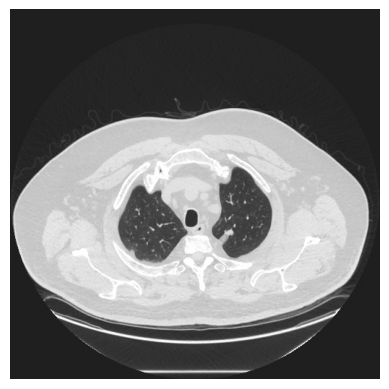

In [4]:
# {'img_name': 'xmlab1/source.jpg', 'location': 'Abdomen', 'answer': 'MRI', 'modality': 'MRI', 'base_type': 'vqa', 'answer_type': 'OPEN', 'question': 'What modality is used to take this image?', 'qid': 0, 'content_type': 'Modality', 'triple': ['vhead', '_', '_'], 'img_id': 1, 'q_lang': 'en'}
# i want to visualize all the information in this sample
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os 

# Print all the information in the sample
sample = test_dataset[0]
for key, value in sample.items():
    print(f"{key}: {value}")

# Visualize the image
root = '/mnt/my_ebs_volume/home/ubuntu/Multimodal-Uncertainty-Quantification/dataset/SLAKE/Slake1.0/imgs'
img_path = os.path.join(root, sample['img_name'])
img = mpimg.imread(img_path)
print('--'*50)
plt.imshow(img)
# plt.title(f"Question: {sample['question']}\nAnswer: {sample['answer']}")
print(f"Question: {sample['question']}\nAnswer: {sample['answer']}")
plt.axis('off')
plt.show()


----------------------------------------------------------------------------------------------------
Question: What modality is used to take this image?
Answer: CT


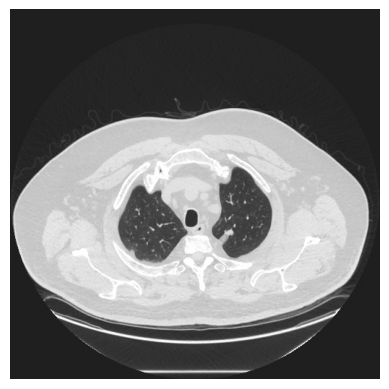

----------------------------------------------------------------------------------------------------
Question: Which part of the body does this image belong to?
Answer: Chest


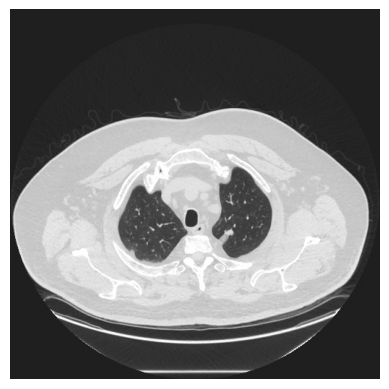

----------------------------------------------------------------------------------------------------
Question: What is the main organ in the image?
Answer: Lung, Spinal Cord


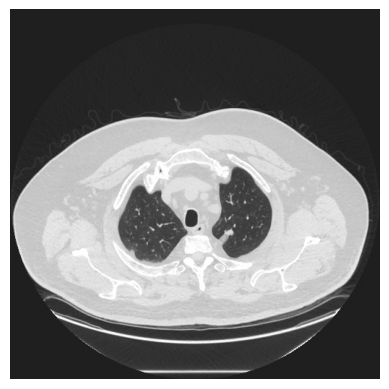

----------------------------------------------------------------------------------------------------
Question: What is the largest organ in the picture?
Answer: Lung


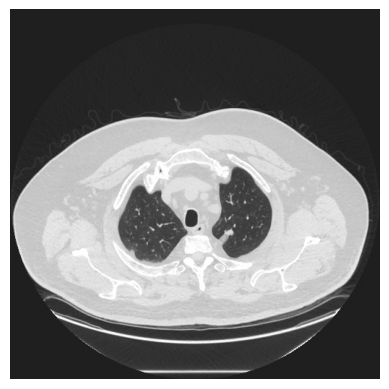

----------------------------------------------------------------------------------------------------
Question: Does the picture contain liver?
Answer: No


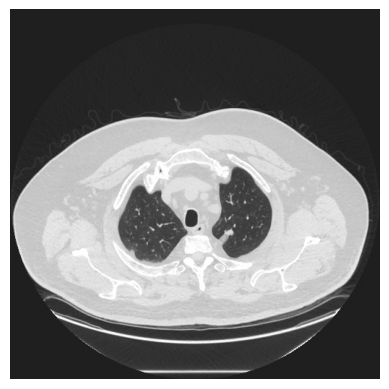

In [5]:
# get some more questions from the dataset 
# and visualize them
for i in range(5):
    sample = test_dataset[i]
    img_path = os.path.join(root, sample['img_name'])
    img = mpimg.imread(img_path)
    print('--'*50)
    plt.imshow(img)
    print(f"Question: {sample['question']}\nAnswer: {sample['answer']}")
    plt.axis('off')
    plt.show()

### Medical VLMs 

In [2]:
import torch
from medpalm.model import MedPalm

#usage
img = torch.randn(1, 3, 256, 256)
text = torch.randint(0, 20000, (1, 4096))

model = MedPalm()
output = model(img, text)
# print(output.shape)


In [5]:
output[0].shape

torch.Size([1, 4095, 20000])

In [1]:
# todays date is 20th January 2025, i want to visualize the accuracy of the model
path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/runs_slake/llava_med_slake/uncertainty_with_gr_biomedclip/uncertainty_scores_baseline.pkl'
import pickle
with open(path, 'rb') as f:
    data = pickle.load(f)

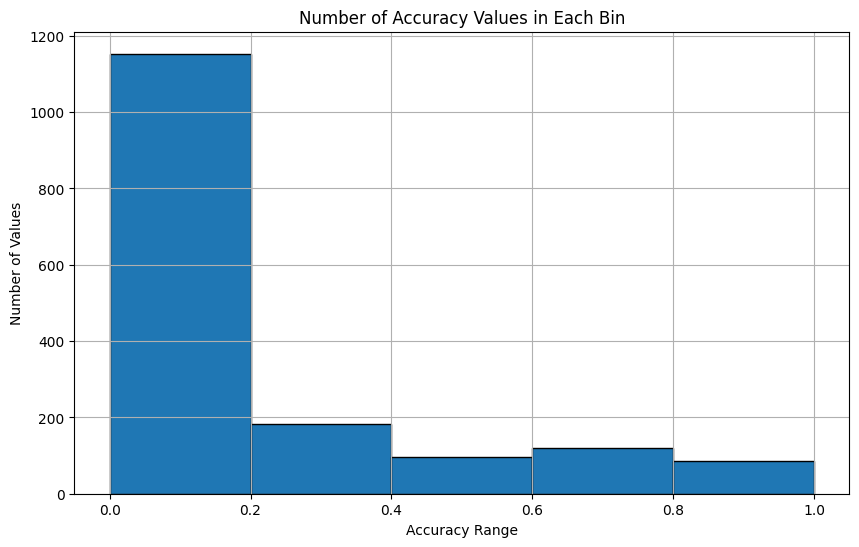

In [5]:
# get all the accuracy values
# I want to see the accuracy values for the test dataset, bin wise
accuracy_values = []
for i in data.keys():
    accuracy_values.append(data[i]['accuracy'])
    
# now plot the accuracy values

import matplotlib.pyplot as plt
import numpy as np

# Plot the accuracy values
# plt.figure(figsize=(10, 6))
# plt.plot(accuracy_values, marker='o', linestyle='-', color='b')
# plt.title('Accuracy Values for Test Dataset (Bin-wise)')
# plt.xlabel('Bin Index')
# plt.ylabel('Accuracy')
# plt.grid(True)
# plt.show()

# Define the bins
bins = np.arange(0, 1.2, 0.2)  # Bins from 0 to 1 with a step of 0.2

# Calculate the histogram
hist, bin_edges = np.histogram(accuracy_values, bins=bins)

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.bar(bin_edges[:-1], hist, width=0.2, edgecolor='black', align='edge')
plt.title('Number of Accuracy Values in Each Bin')
plt.xlabel('Accuracy Range')
plt.ylabel('Number of Values')
plt.xticks(bin_edges)
plt.grid(True)
plt.show()